In [1]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import optuna
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
# os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [3]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test



In [4]:
#Now construct the training, dev and test sets with 168 possible features being the 168 hourly past prices
def create_sliding_window(data_df, window_days=7, forecast_horizon=24):
    """
    Create sliding windows for day-ahead electricity price forecasting.
    Each input corresponds to `window_days` past days (window_days * 24 hours),
    and each output corresponds to the next day's 24 hourly prices.

    Parameters
    ----------
    data_df : pd.DataFrame
        Must contain a 'EUR/MWh' column with hourly prices.
    window_days : int
        Number of past days (each 24 hours) used as input.
    forecast_horizon : int
        Typically 24 (hours in the day to forecast).

    Returns
    -------
    X : np.ndarray of shape (n_samples, window_days*24)
    y : np.ndarray of shape (n_samples, forecast_horizon)
    """
    series = data_df['EUR/MWh'].values
    hours_per_day = 24
    window_size = window_days * hours_per_day

    X, y, y_day_before, y_week_before = [], [], [], []

    for i in range(0, len(series) - window_size - forecast_horizon + 1):
        # Input window: past `window_size` hours
        X_window = series[i : i + window_size]
        # Target: next `forecast_horizon` hours
        y_target = series[i + window_size : i + window_size + forecast_horizon]

        # --- Naive baselines ---
        # previous day
        if i - hours_per_day >= 0:
            y_prev_day = series[i + window_size - hours_per_day : i + window_size - hours_per_day + forecast_horizon]
        else:
            y_prev_day = np.full(forecast_horizon, np.nan)

        # previous week
        if i - 7 * hours_per_day >= 0:
            y_prev_week = series[i + window_size - 7 * hours_per_day : i + window_size - 7 * hours_per_day + forecast_horizon]
        else:
            y_prev_week = np.full(forecast_horizon, np.nan)

        X.append(X_window)
        y.append(y_target)
        y_day_before.append(y_prev_day)
        y_week_before.append(y_prev_week)

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), np.asarray(y_day_before, dtype=np.float32), np.asarray(y_week_before, dtype=np.float32)

In [5]:

# --- Model (MLP) similar structure to Rolling window notebook ---
class MLP(nn.Module):
    def __init__(self, input_dim, layer_dims, output_dim, dropout=0.0, use_batchnorm=False, leaky_alpha=0.0):
        super().__init__()
        layers = []
        last = input_dim
        for i, d in enumerate(layer_dims):
            layers.append(nn.Linear(last, d))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(d, eps=1e-3, momentum=0.99))
            if leaky_alpha and leaky_alpha > 0:
                layers.append(nn.LeakyReLU(leaky_alpha))
            else:
                layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = d
        layers.append(nn.Linear(last, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [6]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [7]:
def naive_baseline(y_np, shift=24*7):
    out = np.empty_like(y_np, dtype=float)
    out[:shift, :] = np.nan
    out[shift:, :] = y_np[:-shift, :]
    return out


In [8]:
def evaluate_model(
    model, X_np, y_np, y_np_1d, y_np_7d, std_FR, mean_FR,
    shift=7*24, batch_size=128, device='cpu'
):
    """
    Evaluate a model that predicts 24-hour-ahead electricity prices.
    Each y_np[i] and prediction[i] corresponds to one day (24 hourly values).

    shift = 7 → naive forecast uses the same hour one week before.
    """
    model.to(device)
    model.eval()
    preds = []

    # --- Forward pass in batches ---
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            out = model(xb).cpu().numpy()
            preds.append(out)
    predictions = np.vstack(preds)

    # --- Denormalize ---
    predictions = predictions * std_FR + mean_FR
    y_np = y_np * std_FR + mean_FR
    y_np_1d = y_np_1d * std_FR + mean_FR
    y_np_7d = y_np_7d * std_FR + mean_FR
    # --- Simple metrics ---
    mae_model_full = np.mean(np.abs(predictions - y_np))
    median = np.median(y_np)
    mae_median = np.mean(np.abs(median - y_np))
    maem = mae_model_full / mae_median

    # --- rMAE with 1-day shift (naive forecast = previous day’s actuals) ---
    preds_trim_1d = predictions[24:]
    true_1d = y_np[24:]
    naive_vals_1d = y_np_1d[24:]
    mae_naive_1d = np.mean(np.abs(naive_vals_1d - true_1d))
    mae_model_r_1d = np.mean(np.abs(preds_trim_1d - true_1d))
    rMAE_1d = mae_model_r_1d / mae_naive_1d

    # --- rMAE with 7-day shift (naive forecast = previous week’s actuals) ---
    if len(y_np) <= shift:
        raise ValueError("Not enough samples to compute naive baseline (need > shift samples).")

    preds_trim_7d = predictions[shift:]
    true_7d = y_np[shift:]
    naive_vals_7d = y_np_7d[shift:]
    mae_naive_7d = np.mean(np.abs(naive_vals_7d - true_7d))
    mae_model_r_7d = np.mean(np.abs(preds_trim_7d - true_7d))
    rMAE_7d = mae_model_r_7d / mae_naive_7d

    print(f"MAE: {mae_model_full:.6f}, MAEm: {maem:.6f}, rMAE (1 day): {rMAE_1d:.6f}, rMAE (7 days): {rMAE_7d:.6f}")
    return {
        "predictions": predictions,
        "MAE": mae_model_full,
        "MAEm": maem,
        "rMAE (1 day)": rMAE_1d,
        "rMAE (7 days)": rMAE_7d,
    }


In [9]:
def run_full_train(
        X_train_np, y_train_np, X_dev_np, y_dev_np,
        layer_dims,
        dropout,
        use_batchnorm,
        leaky_alpha,
        learning_rate,
        weight_decay,
        l1_lambda,
        batch_size,
        train_amt,
        epochs,
        verbose_freq=1,
        device='cpu'
    ):

    # --- Use only the first 'train_amt' features (columns) ---
    X_train_np = X_train_np[:, :train_amt]
    X_dev_np = X_dev_np[:, :train_amt]

    input_dim = X_train_np.shape[1]
    output_dim = y_train_np.shape[1]

    MODEL = MLP(
        input_dim=input_dim,
        layer_dims=layer_dims,
        output_dim=output_dim,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha
    ).to(device)

    optimizer = torch.optim.Adam(
        MODEL.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )


    print("Model:")
    print(MODEL)
    print("Optimizer:", optimizer)
    print(f"Batch size: {batch_size}, Epochs: {epochs}")

    train_hist = []
    val_hist = []

    # --- Convert to tensors once ---
    X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32, device=device)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32, device=device)
    X_dev_tensor = torch.tensor(X_dev_np, dtype=torch.float32, device=device)
    y_dev_tensor = torch.tensor(y_dev_np, dtype=torch.float32, device=device)

    for epoch in range(epochs):
        # --- Shuffle training data ---
        perm = torch.randperm(X_train_tensor.size(0))
        X_shuf = X_train_tensor[perm]
        y_shuf = y_train_tensor[perm]

        MODEL.train()
        epoch_train_loss = 0.0

        for i in range(0, X_shuf.size(0), batch_size):
            xb = X_shuf[i:i+batch_size]
            yb = y_shuf[i:i+batch_size]

            optimizer.zero_grad()
            pred = MODEL(xb)
            loss = mae_loss_fn(pred, yb)

            if l1_lambda and l1_lambda > 0:
                l1_reg = sum(torch.sum(torch.abs(p)) for p in MODEL.parameters())
                loss = loss + l1_lambda * l1_reg

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * xb.size(0)

        epoch_train_loss /= X_shuf.size(0)
        train_hist.append(epoch_train_loss)

        # --- Validation ---
        MODEL.eval()
        with torch.no_grad():
            preds = MODEL(X_dev_tensor)
            val_loss = mae_loss_fn(preds, y_dev_tensor).item()

        val_hist.append(val_loss)
        

        if verbose_freq and (epoch % verbose_freq == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {val_loss:.6f}")

    return MODEL, train_hist, val_hist


In [10]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)

df_FR = pd.read_csv(DATA_CSV_FR)

train_df_FR, dev_df_FR, test_df_FR = split_data(df_FR)
#Normalization
mean_FR = train_df_FR['EUR/MWh'].mean()
std_FR = train_df_FR['EUR/MWh'].std()
train_df_FR['EUR/MWh'] = (train_df_FR['EUR/MWh'] - mean_FR) / std_FR
dev_df_FR['EUR/MWh'] = (dev_df_FR['EUR/MWh'] - mean_FR) / std_FR
test_df_FR['EUR/MWh'] = (test_df_FR['EUR/MWh'] - mean_FR) / std_FR




In [11]:


# --- Create sliding windows per country ---
window_days = 7
forecast_horizon = 24
X_train_FR, y_train_FR, y_train_FR_1d, y_train_FR_7d = create_sliding_window(train_df_FR, window_days=7, forecast_horizon=24)
X_dev_FR,   y_dev_FR,   y_dev_FR_1d, y_dev_FR_7d = create_sliding_window(dev_df_FR, window_days=7, forecast_horizon=24)
X_test_FR,  y_test_FR,  y_test_FR_1d, y_test_FR_7d = create_sliding_window(test_df_FR, window_days=7, forecast_horizon=24)
print("Combined training samples:", X_train_FR.shape, y_train_FR.shape)
print("Combined dev samples:", X_dev_FR.shape, y_dev_FR.shape)
print("Combined test samples:", X_test_FR.shape, y_test_FR.shape)




Combined training samples: (34869, 168) (34869, 24)
Combined dev samples: (8592, 168) (8592, 24)
Combined test samples: (8568, 168) (8568, 24)


In [12]:

# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": {
        "layer_dims": [24],  #[168,24,1] (lr 1e-4) works good [168,48,24] (lr (5e-5)) as well
        "dropout": 0.0,
        "use_batchnorm": False,
        "leaky_alpha": 0.0,
        "learning_rate": 1e-4,
        "weight_decay": 0.0,
        "l1_lambda": 1e-3,
        "batch_size": 128,
        "train_amt": len(X_train_FR),   # use all by default
        "epochs": 100
     },
}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_train_FR, y_train_FR, X_dev_FR, y_dev_FR,
        layer_dims = params["layer_dims"],
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        train_amt = params["train_amt"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, X_dev_FR, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, std_FR=std_FR, mean_FR=mean_FR, device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Running experiment: default
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=24, bias=True)
    (1): ReLU()
    (2): Linear(in_features=24, out_features=24, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0
)
Batch size: 128, Epochs: 100
Epoch 1/100 | Train Loss: 0.625746 | Val Loss: 0.209411
Epoch 2/100 | Train Loss: 0.437326 | Val Loss: 0.200211
Epoch 3/100 | Train Loss: 0.379156 | Val Loss: 0.194171
Epoch 4/100 | Train Loss: 0.343926 | Val Loss: 0.189832
Epoch 5/100 | Train Loss: 0.319385 | Val Loss: 0.187039
Epoch 6/100 | Train Loss: 0.301762 | Val Loss: 0.185178
Epoch 7/100 | Train Loss: 0.289250 | Val Loss: 0.182831
Epoch 8/100 | Train Loss: 0.279973 | Val Loss: 0.180623
Epoch 9/100 | Train Loss: 0.272544 | Val Loss: 0.1

<Figure size 640x480 with 0 Axes>

In [13]:
#Hyperparameer searching
architectures = [[],[1],
                [24],
                [48,24],
                [168,24,1],
                [168,48,24]]
lr=np.logspace(-5,-3,5)
results={}
#Train for each of the parameter combinations on 50 epochs
for arch in architectures:
    for learning_rate in lr:
        print(f"Training architecture {arch} with learning rate {learning_rate}")
        model, train_hist, val_hist = run_full_train(
            X_train_FR, y_train_FR, X_dev_FR, y_dev_FR,
            layer_dims = arch,
            dropout = 0.0,
            use_batchnorm = False,
            leaky_alpha = 0.0,
            learning_rate = learning_rate,
            weight_decay = 0.0,
            l1_lambda = 0.0,
            batch_size = 128,
            train_amt = len(X_train_FR),
            epochs = 50,
            verbose_freq = 10
        )
        print("Evaluating on dev set:")
        eval_res = evaluate_model(model, X_dev_FR, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, std_FR=std_FR, mean_FR=mean_FR, device=device)
        print("\n")
        results[(tuple(arch), learning_rate)] = eval_res
#Find the best architecture and learning rate
min_mae=min([v['MAE'] for v in results.values()])
min_maem=min([v['MAEm'] for v in results.values()])
min_rmae1=min([v['rMAE (1 day)'] for v in results.values()])
min_rmae7=min([v['rMAE (7 days)'] for v in results.values()])
best_configs_mae=[k for k,v in results.items() if v['MAE']==min_mae]
best_configs_maem=[k for k,v in results.items() if v['MAEm']==min_maem]
best_configs_rmae1=[k for k,v in results.items() if v['rMAE (1 day)']==min_rmae1]
best_configs_rmae7=[k for k,v in results.items() if v['rMAE (7 days)']==min_rmae7]
print(f"Best configurations for minimum MAE ({min_mae}):")
for config in best_configs_mae:
    print(f"Architecture: {config[0]}, Learning Rate: {config[1]}")
print(f"Best configurations for minimum MAEm ({min_maem}):")
for config in best_configs_maem:
    print(f"Architecture: {config[0]}, Learning Rate: {config[1]}")
print(f"Best configurations for minimum rMAE (1 day) ({min_rmae1}):")
for config in best_configs_rmae1:
    print(f"Architecture: {config[0]}, Learning Rate: {config[1]}")
print(f"Best configurations for minimum rMAE (7 days) ({min_rmae7}):")
for config in best_configs_rmae7:
    print(f"Architecture: {config[0]}, Learning Rate: {config[1]}")


Training architecture [] with learning rate 9.999999999999999e-06
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=24, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 9.999999999999999e-06
    maximize: False
    weight_decay: 0.0
)
Batch size: 128, Epochs: 50
Epoch 1/50 | Train Loss: 0.692275 | Val Loss: 0.448136
Epoch 11/50 | Train Loss: 0.241520 | Val Loss: 0.203975
Epoch 21/50 | Train Loss: 0.197645 | Val Loss: 0.170065
Epoch 31/50 | Train Loss: 0.178746 | Val Loss: 0.154765
Epoch 41/50 | Train Loss: 0.170197 | Val Loss: 0.148250
Epoch 50/50 | Train Loss: 0.165465 | Val Loss: 0.144724
Evaluating on dev set:
MAE: 18.299860, MAEm: 0.554089, rMAE (1 day): 0.892659, rMAE (7 days): 0.657481


Training architecture [] with learning rate 3.1622776601683795e-05
Model:
MLP(
  (

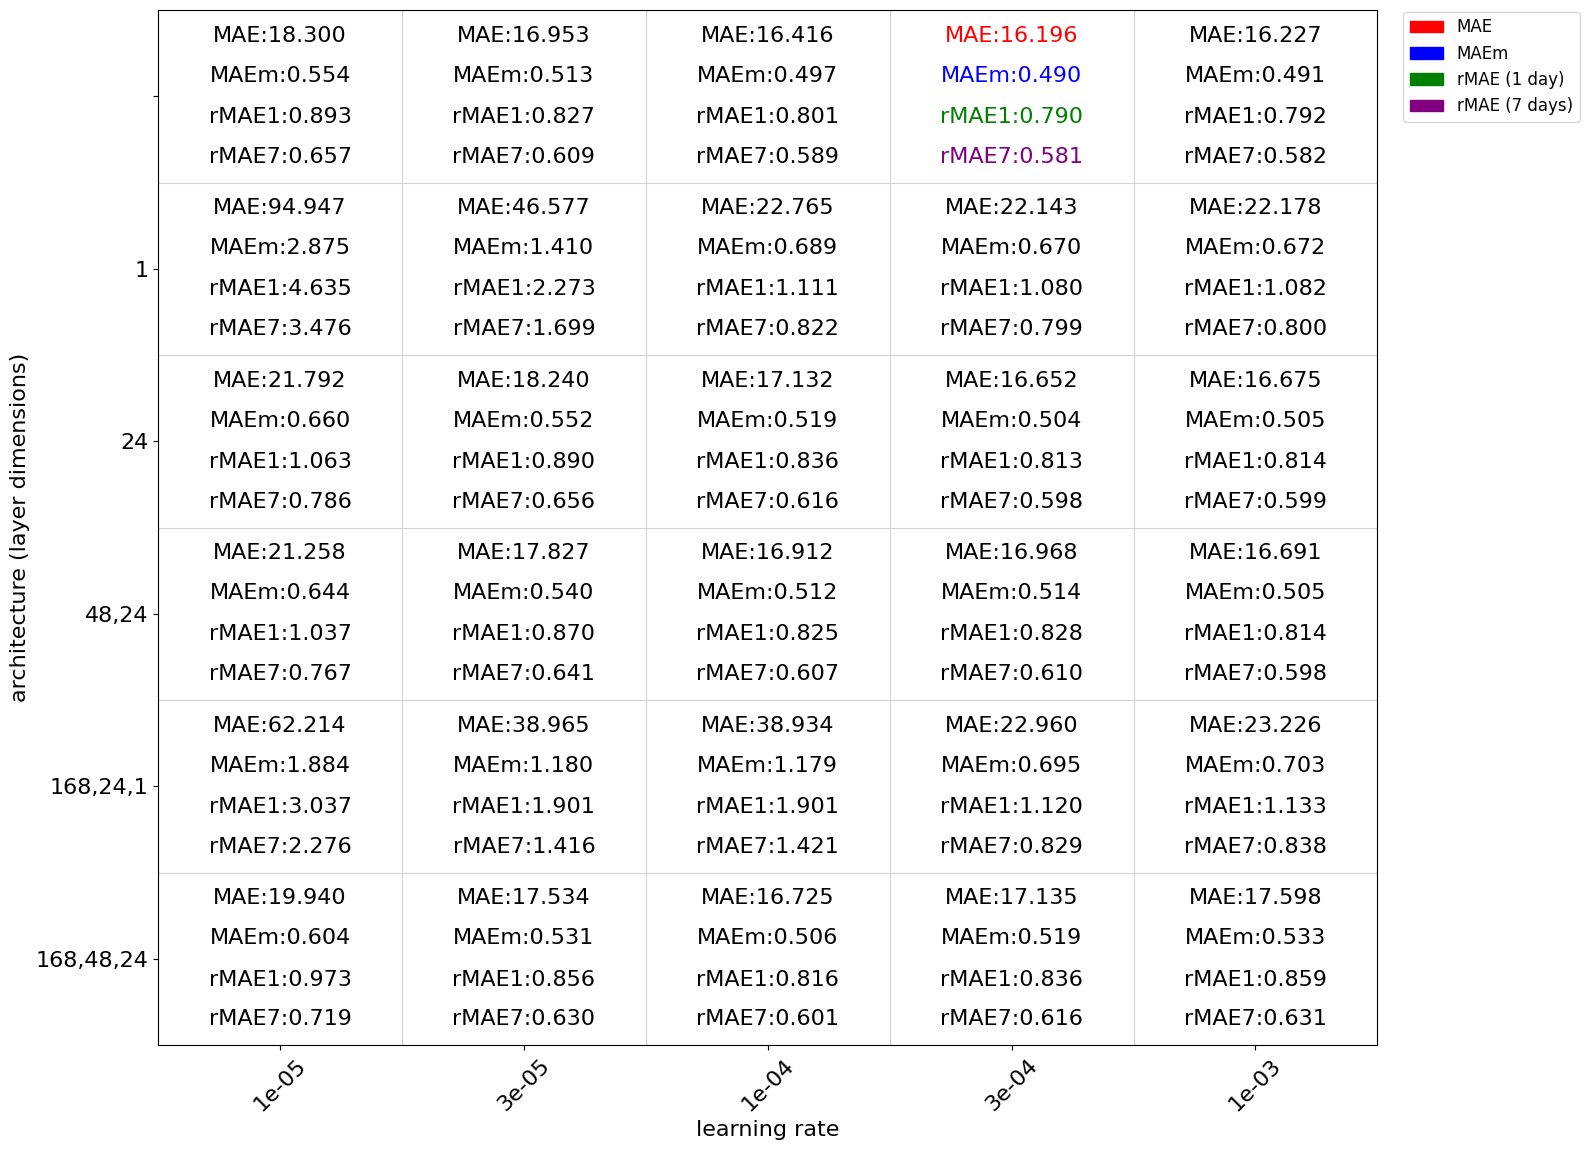

In [31]:
# ...existing code...
# This cell: build short labels, fill matrices, find minima and plot grid with metric-text colored per-minimum
# collect unique architectures and lrs (same ordering as rMAE plot)
archs = sorted({k[0] for k in results.keys()}, key=lambda a: (len(a), a))
lrs = sorted({float(k[1]) for k in results.keys()})

# metrics to show in each grid cell
metric_keys = ["MAE", "MAEm", "rMAE (1 day)", "rMAE (7 days)"]

# prepare matrices for each metric and multiline text for annotations
metrics_mats = {mk: np.full((len(archs), len(lrs)), np.nan, dtype=float) for mk in metric_keys}
cell_text = np.full((len(archs), len(lrs)), "", dtype=object)

for (arch, lr) in results.keys():
    v = results[(arch, lr)]
    if isinstance(v, dict) and "eval" in v and isinstance(v["eval"], dict):
        ev = v["eval"]
    elif isinstance(v, dict) and any(k in v for k in metric_keys):
        ev = v
    else:
        ev = None

    i = archs.index(arch)
    j = lrs.index(float(lr))

    if ev is None:
        cell_text[i, j] = "no eval"
        continue

    # use short, unambiguous labels so rMAE (1 day) / (7 days) are distinct in the cell text
    short_labels = {
        "MAE": "MAE",
        "MAEm": "MAEm",
        "rMAE (1 day)": "rMAE1",
        "rMAE (7 days)": "rMAE7",
    }

    parts = []
    for mk in metric_keys:
        val = ev.get(mk, np.nan)
        try:
            valf = float(val)
        except Exception:
            valf = np.nan
        metrics_mats[mk][i, j] = valf
        lab = short_labels.get(mk, mk.split()[0])
        parts.append(f"{lab}:{valf:.3f}" if not np.isnan(valf) else f"{lab}:nan")
    cell_text[i, j] = "\n".join(parts)

# --- find minimum positions for each metric (ignore NaNs) ---
min_positions = {}
for mk in metric_keys:
    mat = metrics_mats[mk]
    if np.all(np.isnan(mat)):
        min_positions[mk] = []
    else:
        min_val = np.nanmin(mat)
        # positions as (row, col) tuples
        pos = list(zip(*np.where(np.isclose(mat, min_val, atol=1e-12))))
        min_positions[mk] = pos

# --- Plot grid WITHOUT heatmap, annotate every cell with 4 metrics and highlight minima ---
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(16, 8 + 0.6 * len(archs)))
ax.set_xlim(-0.5, len(lrs) - 0.5)
ax.set_ylim(len(archs) - 0.5, -0.5)  # origin at top to match previous layout
# set_xticks / set_yticks do not accept fontsize; set font size via set_xticklabels / set_yticklabels
ax.set_xticks(range(len(lrs)))
ax.set_xticklabels([f"{lr:.0e}" for lr in lrs], fontsize=16, rotation=45)
ax.set_yticks(range(len(archs)))
ax.set_yticklabels([",".join(map(str, a)) for a in archs], fontsize=16)
ax.set_xlabel("learning rate", fontsize=16)
ax.set_ylabel("architecture (layer dimensions)", fontsize=16)

# draw light grid lines
for x in range(len(lrs) + 1):
    ax.axvline(x - 0.5, color='lightgray', linewidth=0.8)
for y in range(len(archs) + 1):
    ax.axhline(y - 0.5, color='lightgray', linewidth=0.8)

# colors for each metric's minima (kept distinct)
colors = ['red', 'blue', 'green', 'purple']
metric_colors = {mk: colors[idx % len(colors)] for idx, mk in enumerate(metric_keys)}
legend_patches = [patches.Patch(color=metric_colors[mk], label=mk) for mk in metric_keys]

# annotate every cell with the 4 metrics as separate text items, color the line if it's a metric minimum
# vertical offsets inside a cell (from top to bottom rows use negative->positive relative to center)
y_offsets = [-0.35, -0.12, 0.12, 0.35]

for i in range(len(archs)):
    for j in range(len(lrs)):
        ev_lines = cell_text[i, j].split("\n") if (cell_text[i, j] and isinstance(cell_text[i, j], str)) else []
        if not ev_lines:
            ax.text(j, i, "no eval", ha='center', va='center', fontsize=7, color='gray')
            continue

        # for each metric place a separate text entry with its own color (default black)
        for k, mk in enumerate(metric_keys):
            line = ev_lines[k] if k < len(ev_lines) else ""
            if not line:
                continue
            # default color
            txt_color = 'black'
            # if this (i,j) is one of the minima positions for this metric, color the metric text
            if (i, j) in min_positions.get(mk, []):
                txt_color = metric_colors[mk]
            ax.text(j, i + y_offsets[k], line, ha='center', va='center', fontsize=16, color=txt_color)

# place legend outside plot to the right
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, borderaxespad=0.1)

plt.tight_layout()
plt.savefig("metrics_grid_minima_text_colored.png", bbox_inches='tight')
plt.show()
# ...existing code...

In [34]:
def objective(trial):
    # --- Hyperparameters to tune ---
        # --- Architecture search ---
    n_layers = trial.suggest_int("n_layers", 1, 2)
    # Choose number of neurons for each layer
    neuron_choices = [k for k in range(1,169)]
    layer_dims = [trial.suggest_categorical(f"n_units_l{i}", neuron_choices) for i in range(n_layers)]
    
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-1)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-7, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    train_amt = trial.suggest_categorical("train_amt", [168])
    epochs = 50  # you can reduce for faster search

    # --- Train model ---
    MODEL, train_hist, val_hist = run_full_train(
        X_train_np=X_train_FR, y_train_np=y_train_FR,
        X_dev_np=X_dev_FR, y_dev_np=y_dev_FR,
        layer_dims=layer_dims,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        train_amt=train_amt,
        epochs=epochs,
        verbose_freq=None
    )

    # --- Evaluate on dev set ---
    metrics = evaluate_model(MODEL, X_dev_FR[:, :train_amt], y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, std_FR, mean_FR)
    mae=metrics["MAE"]
    maem=metrics["MAEm"]
    rmae_1d=metrics["rMAE (1 day)"]  # smaller = better
    rmae_7d=metrics["rMAE (7 days)"]  # smaller = better

    return mae,maem, rmae_1d, rmae_7d
# --- Run the study ---
study = optuna.create_study(directions=["minimize","minimize","minimize","minimize"])    
study_name="FR_LMP_MLP"
study.optimize(objective, n_trials=50, timeout=None)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.")

for t in best_trials:
    print(f"Values: {t.values}")
    print(f"Params: {t.params}")



[I 2025-11-10 23:56:10,408] A new study created in memory with name: no-name-19890ece-803e-48fa-b6d7-283c2ab653ec
/tmp/ipykernel_4487/3656436834.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-1)
/tmp/ipykernel_4487/3656436834.py:13: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
/tmp/ipykernel_4487/3656436834.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  l1_lambda = t

Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=151, bias=True)
    (1): LeakyReLU(negative_slope=0.014187283206682656)
    (2): Dropout(p=0.012670724928736998, inplace=False)
    (3): Linear(in_features=151, out_features=86, bias=True)
    (4): LeakyReLU(negative_slope=0.014187283206682656)
    (5): Dropout(p=0.012670724928736998, inplace=False)
    (6): Linear(in_features=86, out_features=24, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.00020992422368502152
    maximize: False
    weight_decay: 1.8759747111058772e-06
)
Batch size: 64, Epochs: 50


[I 2025-11-10 23:57:21,374] Trial 0 finished with values: [20.416906356811523, 0.6181897521018982, 0.9965298175811768, 0.7374535799026489] and parameters: {'n_layers': 2, 'n_units_l0': 151, 'n_units_l1': 86, 'dropout': 0.012670724928736998, 'use_batchnorm': False, 'leaky_alpha': 0.014187283206682656, 'learning_rate': 0.00020992422368502152, 'weight_decay': 1.8759747111058772e-06, 'l1_lambda': 0.0006041084407567527, 'batch_size': 64, 'train_amt': 168}.


MAE: 20.416906, MAEm: 0.618190, rMAE (1 day): 0.996530, rMAE (7 days): 0.737454
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=85, bias=True)
    (1): BatchNorm1d(85, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.05479135053671287)
    (3): Dropout(p=0.20957082487958417, inplace=False)
    (4): Linear(in_features=85, out_features=24, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.06412932375237687
    maximize: False
    weight_decay: 9.075681788096935e-05
)
Batch size: 128, Epochs: 50


[I 2025-11-10 23:57:56,762] Trial 1 finished with values: [24.869115829467773, 0.7529951930046082, 1.2133264541625977, 0.8987042307853699] and parameters: {'n_layers': 1, 'n_units_l0': 85, 'dropout': 0.20957082487958417, 'use_batchnorm': True, 'leaky_alpha': 0.05479135053671287, 'learning_rate': 0.06412932375237687, 'weight_decay': 9.075681788096935e-05, 'l1_lambda': 7.5285634884709214e-06, 'batch_size': 128, 'train_amt': 168}.


...

MAE: 23.087057, MAEm: 0.699037, rMAE (1 day): 1.126797, rMAE (7 days): 0.834796
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=79, bias=True)
    (1): LeakyReLU(negative_slope=0.13935841735879526)
    (2): Dropout(p=0.19549095991921905, inplace=False)
    (3): Linear(in_features=79, out_features=40, bias=True)
    (4): LeakyReLU(negative_slope=0.13935841735879526)
    (5): Dropout(p=0.19549095991921905, inplace=False)
    (6): Linear(in_features=40, out_features=24, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 7.694374823371138e-05
    maximize: False
    weight_decay: 0.0008979016163308116
)
Batch size: 64, Epochs: 50


[I 2025-11-11 00:25:04,675] Trial 48 finished with values: [18.760982513427734, 0.5680511593818665, 0.9160259366035461, 0.6766847968101501] and parameters: {'n_layers': 2, 'n_units_l0': 79, 'n_units_l1': 40, 'dropout': 0.19549095991921905, 'use_batchnorm': False, 'leaky_alpha': 0.13935841735879526, 'learning_rate': 7.694374823371138e-05, 'weight_decay': 0.0008979016163308116, 'l1_lambda': 4.761080602055826e-05, 'batch_size': 64, 'train_amt': 168}.


MAE: 18.760983, MAEm: 0.568051, rMAE (1 day): 0.916026, rMAE (7 days): 0.676685
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=24, bias=True)
    (1): LeakyReLU(negative_slope=0.05585116724813499)
    (2): Dropout(p=0.26700784177312537, inplace=False)
    (3): Linear(in_features=24, out_features=24, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.000542280642638573
    maximize: False
    weight_decay: 0.0003510676833678119
)
Batch size: 64, Epochs: 50


[I 2025-11-11 00:25:39,291] Trial 49 finished with values: [20.67815589904785, 0.6260999441146851, 1.0092157125473022, 0.7462612986564636] and parameters: {'n_layers': 1, 'n_units_l0': 24, 'dropout': 0.26700784177312537, 'use_batchnorm': False, 'leaky_alpha': 0.05585116724813499, 'learning_rate': 0.000542280642638573, 'weight_decay': 0.0003510676833678119, 'l1_lambda': 0.0007912415524418258, 'batch_size': 64, 'train_amt': 168}.


MAE: 20.678156, MAEm: 0.626100, rMAE (1 day): 1.009216, rMAE (7 days): 0.746261
Found 1 Pareto-optimal trials.
Values: [16.469324111938477, 0.4986635744571686, 0.8037058711051941, 0.5916462540626526]
Params: {'n_layers': 1, 'n_units_l0': 69, 'dropout': 0.18942302286707113, 'use_batchnorm': False, 'leaky_alpha': 0.17590740724910892, 'learning_rate': 0.0004271435826385541, 'weight_decay': 9.434700468781846e-05, 'l1_lambda': 9.665083152100605e-06, 'batch_size': 256, 'train_amt': 168}


In [35]:

# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": {
        "layer_dims": [],  #[168,24,1] (lr 1e-4) works good [168,48,24] (lr (5e-5)) as well
        "dropout": 0.0,
        "use_batchnorm": False,
        "leaky_alpha": 0.0,
        "learning_rate": 3e-4,
        "weight_decay": 0,
        "l1_lambda": 0,
        "batch_size": 128,
        "train_amt": len(X_train_FR),   # use all by default
        "epochs": 50
     },
     "optuna":{
        "layer_dims": [69],  #[168,24,1] (lr 1e-4) works good [168,48,24] (lr (5e-5)) as well
        "dropout": 0.18942302286707113,
        "use_batchnorm": False,
        "leaky_alpha": 0.17590740724910892,
        "learning_rate": 0.0004271435826385541,
        "weight_decay": 9.434700468781846e-05,
        "l1_lambda": 9.665083152100605e-06,
        "batch_size": 256,
        "train_amt": len(X_train_FR),   # use all by default
        "epochs": 50
         
     }
}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}
for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_train_FR, y_train_FR, X_dev_FR, y_dev_FR,
        layer_dims = params["layer_dims"],
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        train_amt = params["train_amt"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, X_dev_FR, y_dev_FR,y_dev_FR_1d,y_dev_FR_7d, std_FR, mean_FR, device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Running experiment: default
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=24, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)
Batch size: 128, Epochs: 50
Epoch 1/50 | Train Loss: 0.259948 | Val Loss: 0.168741
Epoch 2/50 | Train Loss: 0.181928 | Val Loss: 0.149195
Epoch 3/50 | Train Loss: 0.167314 | Val Loss: 0.142721
Epoch 4/50 | Train Loss: 0.160267 | Val Loss: 0.139125
Epoch 5/50 | Train Loss: 0.156207 | Val Loss: 0.136969
Epoch 6/50 | Train Loss: 0.153493 | Val Loss: 0.135489
Epoch 7/50 | Train Loss: 0.151670 | Val Loss: 0.134522
Epoch 8/50 | Train Loss: 0.150220 | Val Loss: 0.133807
Epoch 9/50 | Train Loss: 0.149086 | Val Loss: 0.133279
Epoch 10/50 | Train Loss: 0.148216 | Val Loss: 0.132588
Epoch 11/50 | Train Loss: 

<Figure size 640x480 with 0 Axes>

In [ ]:

# Pick three days at random on the dev set and plot single-point forecast + naive baseline
num_days = len(X_dev_FR)
random_indices = random.sample(range(num_days), 3)
naive_arr = naive_baseline(y_dev_FR, shift=24*7)   # do NOT shadow the function name

for idx in random_indices:
    input_window = X_dev_FR[idx]
    true_value = float(y_dev_FR[idx].flatten()[0])  # scalar target
    naive_value = float(np.squeeze(naive_arr[idx]))  # scalar (may be nan for early indices)

    model.eval()
    with torch.no_grad():
        input_tensor = torch.from_numpy(input_window).float().unsqueeze(0).to(device)
        pred_val = float(model(input_tensor).cpu().numpy().flatten()[0])

    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(t), input_window, label='Input Window (Past Prices)')
    plt.scatter([t], [true_value], color='green', label='True (t+1)', zorder=5)
    plt.scatter([t], [pred_val], color='red', marker='x', s=80, label='Predicted (t+1)', zorder=6)
    plt.scatter([t], [naive_value], color='orange', label='Naive Baseline (168h before)', zorder=4)
    plt.title(f'Price Prediction for Dev Sample Index {idx}')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Normalized Price (EUR/MWh)')
    plt.legend()
    plt.show()

In [ ]:


# ensure model is available
_ = model

# move to CPU for plotting
model_cpu = model.to('cpu')

# collect all Linear layers in the sequential network (in order)
linears = [m for m in model_cpu.net if isinstance(m, nn.Linear)]
if len(linears) == 0:
    raise RuntimeError("No nn.Linear layers found in model.net")

# prepare plot
plt.clf()
fig, axes = plt.subplots(len(linears), 1, figsize=(8, 3 * len(linears)))
if len(linears) == 1:
    axes = [axes]

for i, lin in enumerate(linears):
    W = lin.weight.detach().numpy()   # shape: (out_features, in_features)
    b = lin.bias.detach().numpy() if lin.bias is not None else None

    axes[i].set_title(f"Linear layer {i} — weight shape {W.shape} bias {'yes' if b is not None else 'no'}")
    # if single-row output (common for final layer with single output) plot vector
    if W.ndim == 2 and W.shape[0] == 1:
        axes[i].plot(W.flatten(), marker='o', linestyle='-')
        axes[i].set_xlabel("input index")
        axes[i].set_ylabel("weight value")
    else:
        im = axes[i].imshow(W, aspect='auto', cmap='RdBu_r')
        fig.colorbar(im, ax=axes[i])
        axes[i].set_xlabel("in_features")
        axes[i].set_ylabel("out_features")

    # overlay bias as x marks (if present)
    if b is not None:
        # place biases to the right of inputs for visualization (will align on x axis for vector plots)
        if W.shape[0] == 1:
            axes[i].scatter([len(W.flatten())], [b.item()] if b.size == 1 else b.flatten()[0], color='k', marker='x', label='bias')
        else:
            # plot bias values as a separate small bar plot on the right of the heatmap
            bx = axes[i].inset_axes([1.02, 0.1, 0.08, 0.8])
            bx.barh(np.arange(len(b)), b, color='gray')
            bx.set_title("bias")
        axes[i].legend()

plt.tight_layout()
plt.savefig("model_weights.png", bbox_inches='tight')
plt.show()

# print numeric summaries
for i, lin in enumerate(linears):
    W = lin.weight.detach().numpy()
    b = lin.bias.detach().numpy() if lin.bias is not None else None
    print(f"Layer {i}: W shape={W.shape} ||W||={np.linalg.norm(W):.6f} bias={'none' if b is None else np.linalg.norm(b):.6f}")


In [ ]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, X_test_FR, y_test_FR, device=device)
exp_results[tag]["eval_test"] = eval_res_test

In [ ]:
#Take a random 168 hours window

start = random.randint(0, len(y_dev_FR) - 168 - 1)
window_168 = y_dev_FR[start:start+168]
preds=eval_res['predictions'][start:start+168]
naive_arr = naive_baseline(y_dev_FR, shift=24*7)
naive=naive_arr[start:start+168]
window_168=window_168*std_FR + mean_FR
preds=preds*std_FR + mean_FR
naive=naive*std_FR + mean_FR
#Plot the final predictions on test set
plt.figure(figsize=(10, 5))
plt.plot(preds, label='Model Predictions')
# plt.plot(naive, label='Naive Baseline (168h before)')
plt.plot(window_168, label='True Values')
plt.title('Test Set Predictions vs Naive Baseline')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()